# Snapshot eval catplot — MO battery + EV, per comparability group

Compares **per-episode eval metrics** of the multi-objective `sta_lin_battery_EV` trial (linear
battery plus EV charger) against the rule-based baselines, **one comparability group at a time**.

## Why groups

A snapshot's rule-based (RBC) eval replays the episodes of *that snapshot's own* trial config, so
an RBC result only transfers to snapshots sharing it. Two things break that here:

| Axis | What differs | Consequence |
|---|---|---|
| **Eval dataset** | the `_eval_ch` snapshots re-evaluate the *same checkpoint* on the **training** EV profiles (`data/ev_usage_profiles/ev_0…5.csv`) instead of the held-out `ev_eval_0…3.csv` — the only diff in their `code/configs/schedules/data/eval.yaml` | different episode population → `cum_E_kWh` / `cum_price_EUR` / RBC baselines are not comparable |
| **Reward stack** | `old` scores under `EVChargingRewardV0`, `regulator` adds `BESRegulatorReward` + `EVRegulatorReward`, `v2` raises `charge_progress_scale` 0.5 → 10 | `total_reward` sits on a different scale |

So `v2` may not be put beside `v2_eval_ch`, and neither may their RBC strips. `SNAPSHOT_GROUPS`
declares one group per reward/eval variant; `ACTIVE_GROUPS` picks which are drawn. Each active
group produces its **own** set of figures and tables, tagged with the group name — swap
`ACTIVE_GROUPS` and re-run to regenerate everything for a different group.

A group's RBC strips come from **one** designated member (`rbc-ref`). The other members' RBC runs
are not pooled — that would draw the same episodes several times — but they *are* audited against
the reference, and any disagreement is reported.

## What this notebook produces, per active group

1. **Catplots** — x-axis carries the algorithms (PPO, SAC) plus an **RBC** group of rule-based
   strategies; within each slot the variants are dodged. One dot per eval episode, coloured by
   variant, with a **stat glyph** beside it (mean, mean ± 1 std, median, min, max).
2. **Per-strip statistics** and **across-seed variance** tables.
3. **EV charging success table** — how many charging sessions reached the target SoC, counted
   from the eval trajectories both at the reward's tolerance and strictly.
4. **BES management summary** — how the battery is used, with two independent flags for
   "discharges early and never really comes back", plus a mean hour-of-day power profile.

## Data discovery

All eval runs of a source's eval kind are pooled (default run plus `_seed<N>` fan-outs).
Duplicate (setting, seed) CSVs within a source are dropped with a note, since the same checkpoint
on the same seed and setting replays identical episodes — the **first** in `(setting, run, file)`
order wins, so a source with two eval runs on seed 42 keeps the older one unless `runs` pins it.
A source whose snapshot has no eval results yet is skipped with a warning.

`SEEDS` narrows every source to one seed (`42`), a list (`[42, 43]`, pooled) or all (`None`).
The seed matched against is the one each run recorded in its **own metadata** — sidecar JSON
`"seed"` for `eval-ray`/`eval-sb`, `args.json` `"resolved_seed"` for `eval-rbc` — never the
directory name.

Two result layouts are discovered at once and kept apart as separate **settings** (`EVAL_CFGS`
picks which are drawn):

| Layout | Result CSVs | Setting label |
|---|---|---|
| STA (single eval config) | `eval_results/*_eval/eval_*.csv` | `default` |
| GEN (held-out configs) | `eval_results/*_eval/<name>_eval_<i>/eval_*.csv` | `eval_<i>` |

Eval kinds:

| `eval-kind` | Run directory pattern | Producer | Per-run CSV |
|---|---|---|---|
| `eval-ray` | `runs/eval_<ts>/` | Ray RLlib eval (`run_eval_ray.py`) | `eval_*.csv` |
| `eval-sb` | `runs/eval_sb_<ts>/` | SB3 eval (`run_eval_sb.py`) | `eval_*.csv` |
| `eval-rbc` | `runs/eval_rbc_<ts>/` | Rule-based eval (`run_eval_rule_based.py`) | `episodes.csv` |

The `sta_lin_battery_EV` snapshots are all STA, so every figure carries the setting label
`default`.

PDFs are written at **final print size** so `FIGURES_PER_A4_PAGE` (3) of them plus captions fill
one A4 text block — see "Catplots with stat glyphs" below. With a single setting, the three
metrics of one group are exactly one page.

Run the **Imports** cell (right after the main input) before anything else.

**Main input:** `SNAPSHOT_GROUPS`, `ACTIVE_GROUPS`, `RBC_STRATEGIES`, `VARIANT_COLORS`,
`EVAL_CFGS`, `SEEDS` and the EV / BES analysis constants in the next cell.

In [1]:
# --- Main input ---------------------------------------------------------------------
# Snapshots are organised into COMPARABILITY GROUPS. A group is the unit that gets
# swapped: name groups in ACTIVE_GROUPS and re-run the notebook to regenerate every
# figure and table for them. Each active group is drawn on its own, never merged.
#
# Keys per group:
#   label            free-text description; printed in the log, handy for LaTeX captions
#   members          the policy sources drawn on the algorithm slots (keys below)
#   rbc-ref          snapshot whose runs/eval_rbc_* supplies this group's RBC strips.
#                    Only snapshots that actually HOLD a runs/eval_rbc_* directory work
#                    — at the time of writing that is the six PPO snapshots; the SAC ones
#                    carry no rule-based run, and pointing a group at one drops every RBC
#                    strip from that group (loudly: the discovery cell warns per strategy).
#   rbc-strategies   (optional) strategies to draw; defaults to RBC_STRATEGIES
# Keys per member:
#   path             snapshot dir (absolute, or relative to the repo root)
#   algo             x-axis category (also used in the PDF filenames)
#   variant          hue / dodge label inside the algorithm's slot
#   eval-kind        (optional) "eval-ray" | "eval-sb" | "eval-rbc"; default "eval-ray"
#   runs             (optional) restrict to these runs/<name> directories; default: all
#
# A group MAY hold several variants per algorithm (they then dodge side by side, as an
# earlier revision of this notebook drew them). The grouping below is deliberately one
# group per reward/eval variant, so `total_reward` is comparable everywhere inside a
# figure; the audit cell further down warns whenever a group mixes reward stacks or
# eval datasets.

# The 12 sta_lin_battery_EV snapshots, for reference:
#   20260721_093047_sta_lin_battery_EV_ppo              base            PPO
#   20260721_093047_sta_lin_battery_EV_ppo_eval_ch      base            PPO, eval on training EVs
#   20260721_101901_sta_lin_battery_EV_ppo_v2           v2              PPO
#   20260721_101901_sta_lin_battery_EV_ppo_v2_eval_ch   v2              PPO, eval on training EVs
#   20260721_102122_sta_lin_battery_EV_mo_ppo_old       old rewards     PPO
#   20260721_102226_sta_lin_battery_EV_ppo              regulator       PPO   <- same dir name as base, different run
#   20260721_103047_sta_lin_battery_EV_sac              base            SAC
#   20260721_103047_sta_lin_battery_EV_sac_eval_ch      base            SAC, eval on training EVs
#   20260721_111901_sta_lin_battery_EV_sac_v2           v2              SAC
#   20260721_111901_sta_lin_battery_EV_sac_v2_eval_ch   v2              SAC, eval on training EVs
#   20260722_123922_sta_lin_battery_EV_mo_sac_old       old rewards     SAC
#   20260722_134026_sta_lin_battery_EV_sac              regulator       SAC

SNAPSHOT_GROUPS: dict[str, dict] = {
    "base": {
        "label": "EVChargingSessionReward (charge_progress_scale 0.5) — held-out EV profiles",
        "members": [
            {"path": "snapshots/20260721_093047_sta_lin_battery_EV_ppo", "algo": "PPO", "variant": "base"},
            {"path": "snapshots/20260721_103047_sta_lin_battery_EV_sac", "algo": "SAC", "variant": "base"},
        ],
        "rbc-ref": "snapshots/20260721_093047_sta_lin_battery_EV_ppo",
    },
    "v2": {
        "label": "EVChargingSessionReward (charge_progress_scale 10.0) — held-out EV profiles",
        "members": [
            {"path": "snapshots/20260721_101901_sta_lin_battery_EV_ppo_v2", "algo": "PPO", "variant": "v2"},
            {"path": "snapshots/20260721_111901_sta_lin_battery_EV_sac_v2", "algo": "SAC", "variant": "v2"},
        ],
        "rbc-ref": "snapshots/20260721_101901_sta_lin_battery_EV_ppo_v2",
    },
    "old": {
        "label": "EVChargingRewardV0 (diff_threshold 0.02, soc_diff_multiplier 5.0) — held-out EV profiles",
        "members": [
            {"path": "snapshots/20260721_102122_sta_lin_battery_EV_mo_ppo_old", "algo": "PPO", "variant": "old rewards"},
            {"path": "snapshots/20260722_123922_sta_lin_battery_EV_mo_sac_old", "algo": "SAC", "variant": "old rewards"},
        ],
        "rbc-ref": "snapshots/20260721_102122_sta_lin_battery_EV_mo_ppo_old",
    },
    "regulator": {
        "label": "v2 stack plus BESRegulatorReward + EVRegulatorReward (penalty -1.0 each) — held-out EV profiles",
        "members": [
            {"path": "snapshots/20260721_102226_sta_lin_battery_EV_ppo", "algo": "PPO", "variant": "regulator rewards"},
            {"path": "snapshots/20260722_134026_sta_lin_battery_EV_sac", "algo": "SAC", "variant": "regulator rewards"},
        ],
        "rbc-ref": "snapshots/20260721_102226_sta_lin_battery_EV_ppo",
    },
    "base_eval_ch": {
        "label": "base checkpoints re-evaluated on the TRAINING EV profiles (ev_0…ev_5)",
        "members": [
            {"path": "snapshots/20260721_093047_sta_lin_battery_EV_ppo_eval_ch", "algo": "PPO", "variant": "base"},
            {"path": "snapshots/20260721_103047_sta_lin_battery_EV_sac_eval_ch", "algo": "SAC", "variant": "base"},
        ],
        "rbc-ref": "snapshots/20260721_093047_sta_lin_battery_EV_ppo_eval_ch",
    },
    "v2_eval_ch": {
        "label": "v2 checkpoints re-evaluated on the TRAINING EV profiles (ev_0…ev_5)",
        "members": [
            {"path": "snapshots/20260721_101901_sta_lin_battery_EV_ppo_v2_eval_ch", "algo": "PPO", "variant": "v2"},
            {"path": "snapshots/20260721_111901_sta_lin_battery_EV_sac_v2_eval_ch", "algo": "SAC", "variant": "v2"},
        ],
        "rbc-ref": "snapshots/20260721_101901_sta_lin_battery_EV_ppo_v2_eval_ch",
    },
}

# Groups to draw: a tuple of SNAPSHOT_GROUPS keys, or None for every declared group.
# THIS is the swap point — everything below (figures, stats tables, EV success counts,
# BES summary) is produced per active group and for nothing else.
ACTIVE_GROUPS: tuple[str, ...] | None = ("v2",)

# Rule-based baselines: every strategy listed becomes one strip in the group's "RBC"
# x-axis slot, read from the group's `rbc-ref` snapshot. Drop entries to trim the group;
# a group may override the list with its own "rbc-strategies" key.
RBC_STRATEGIES = (
    "do_nothing",
    "deficit_discharge",
    # "pv_surplus_charge",
    "self_coverage",
    "price_median",
    "price_median_scaled_0.25",
    # "price_median_scaled_0.5",
    # "price_median_scaled_0.75",
    "price_median_autarky",
)

# Episode-dot colour per variant, identical across the algorithm groups. Must cover
# every variant of every ACTIVE group plus the RBC strategies.
VARIANT_COLORS = {
    # RL training variants
    "base": "#3f83d4",
    "v2": "#a855d8",
    "old rewards": "#f7a800",
    "regulator rewards": "#0400f3",
    # RBC strategies (own x-group; the price_median family shares a teal ramp)
    "do_nothing": "#5c6670",
    "deficit_discharge": "#c05746",
    "pv_surplus_charge": "#bfa229",
    "self_coverage": "#4a5899",
    "price_median": "#0f6a60",
    "price_median_scaled_0.25": "#8ec7c0",
    "price_median_scaled_0.5": "#55a79d",
    "price_median_scaled_0.75": "#2c887d",
    "price_median_autarky": "#c26fa1",
}

# The eval settings to draw — one figure per (group, metric, setting). None = every
# setting discovered: the held-out `eval_<i>` configs of the GEN layout (numerically
# sorted), and "default" for a flat STA layout (CSVs directly under eval_results/*_eval/).
# The sta_lin_battery_EV snapshots are STA, so this resolves to ("default",).
EVAL_CFGS: tuple[str, ...] | None = None

# Optional display names for the settings, keyed by the discovered `eval_<i>` label.
# Only used in the console log and the captions you write around the PDFs — the data
# keys and the PDF filenames keep the raw `eval_<i>`. Empty here: the only setting is
# "default", which needs no display name.
EVAL_CFG_LABELS: dict[str, str] = {}

# Eval seeds to keep, applied to every source after discovery:
#   SEEDS = None       keep every discovered seed (default)
#   SEEDS = 42         keep only the eval run seeded 42
#   SEEDS = [42, 43]   keep those two seeds, pooled into each strip
# Matched against the seed every run recorded itself (sidecar JSON "seed" for
# eval-ray/eval-sb, args.json "resolved_seed" for eval-rbc), never the directory name.
SEEDS: int | list[int] | None = [42]

METRICS = ("total_reward", "cum_E_kWh", "cum_price_EUR")

# --- EV charging success ------------------------------------------------------------
# A charging session ends when the charger releases the EV; it counts as met when the
# SoC reached by then is at/above the target. EV_SOC_TOLERANCE mirrors
# EVChargingSessionReward's `disconnect_soc_tolerance` (0.05 in every trial YAML of
# these snapshots), so the "met@tol" column reproduces the verdict the policy was
# actually rewarded on; "met@strict" drops the tolerance.
EV_SOC_TOLERANCE = 0.05

# --- BES management -----------------------------------------------------------------
# Two independent readings of "the battery only discharges early in the day":
#   throughput  — at least EARLY_SHARE_FLAG of the episode's |battery power| happens
#                 before EARLY_HOURS_END, and the episode recharges less than
#                 RECHARGE_RATIO_FLAG of what it discharged;
#   SoC shape   — after its lowest point the SoC never climbs back by more than
#                 SOC_RECOVERY_TOLERANCE, i.e. a drawdown followed by a flat line.
# An episode whose total battery throughput stays below IDLE_THROUGHPUT_KWH is reported
# as "idle" and flagged by neither criterion (an untouched battery is not a drawdown).
EARLY_HOURS_END = 8.0
EARLY_SHARE_FLAG = 0.70
RECHARGE_RATIO_FLAG = 0.20
SOC_RECOVERY_TOLERANCE = 0.02
IDLE_THROUGHPUT_KWH = 0.10
# Battery power below this magnitude counts as idle when charge/discharge direction
# changes are counted, so numerical dust does not inflate the cycle count.
POWER_DEADBAND_KW = 0.05

## Imports

Kept in their own cell, and deliberately the only place that imports anything: the cells below do
filesystem discovery and read hundreds of trajectory files, so they are slow enough to invite an
interrupt. Interrupting a cell **while it is importing** leaves a half-initialised module behind
in `sys.modules`, and every later import of it in that same kernel then fails with something like

```
AttributeError: partially initialized module 'pandas' has no attribute '_pandas_parser_CAPI'
(most likely due to a circular import)
```

That state cannot be repaired from inside the kernel — **restart the kernel** and run this cell
first. Isolating the imports here keeps an interrupted discovery run from causing it.

In [2]:
# Every import used by this notebook. Run this cell first; if it fails with a
# "partially initialized module" AttributeError, restart the kernel (see above) — no
# code below can undo that state.
import hashlib
import json
import re
from datetime import datetime
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from matplotlib.lines import Line2D

In [3]:
EVAL_KINDS = ("eval-ray", "eval-sb", "eval-rbc")

# A held-out eval-config result directory ends in `_eval_<i>` (e.g. battery_lin_power_eval_1);
# training-config directories (e.g. battery_lin_power_3) do not match and are skipped.
_EVAL_CFG_DIR_PATTERN = re.compile(r"(?:^|_)eval_(\d+)$")


# Walk upwards from the cwd until the directory containing snapshots/ is found, so the
# notebook runs both from thesis_eval/ and from the repo root.
def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "snapshots").is_dir():
            return candidate
    raise FileNotFoundError("No 'snapshots/' directory found upwards of the cwd — run inside the repo.")


REPO_ROOT = _find_repo_root()


def _snapshot_dir(path: str) -> Path:
    """Snapshot dir of a source `path`, resolved against the repo root when relative."""
    candidate = Path(path)
    return candidate if candidate.is_absolute() else REPO_ROOT / candidate


# Maps a runs/eval_* directory to its eval kind — mirrors the run-id scheme
# tools/snapshot/submit_snapshot.py builds from --kind.
def _run_dir_eval_kind(run_dir: Path) -> str:
    if run_dir.name.startswith("eval_rbc_"):
        return "eval-rbc"
    if run_dir.name.startswith("eval_sb_"):
        return "eval-sb"
    return "eval-ray"


# `eval_<i>` for a held-out eval-config result dir name, None for anything else.
def _cfg_dir_setting(dir_name: str) -> str | None:
    match = _EVAL_CFG_DIR_PATTERN.search(dir_name)
    return f"eval_{match.group(1)}" if match else None


# Ray/SB3 eval CSVs carry a sidecar JSON (same stem) with the run's trial seed + algorithm.
def _sidecar_seed_and_algorithm(csv_path: Path) -> tuple[int | None, str | None]:
    sidecar = csv_path.with_suffix(".json")
    if not sidecar.is_file():
        return None, None
    try:
        payload = json.loads(sidecar.read_text())
    except (json.JSONDecodeError, OSError):
        return None, None
    return payload.get("seed"), payload.get("algorithm")


# Rule-based runs record resolved_seed in an args.json above episodes.csv (directly
# above the per-strategy dir in the flat layout, one level further up with per-config
# dirs) — walk up towards the run dir and take the first hit.
def _rbc_resolved_seed(csv_path: Path, run_dir: Path) -> int | None:
    for candidate_dir in csv_path.parents:
        args_path = candidate_dir / "args.json"
        if args_path.is_file():
            try:
                return json.loads(args_path.read_text()).get("resolved_seed")
            except (json.JSONDecodeError, OSError):
                return None
        if candidate_dir == run_dir:
            return None
    return None


# Discovers one record per eval CSV of `source` across ALL eval settings kept by
# EVAL_CFGS (None = no filter). Both layouts are globbed; every record is tagged with
# its setting ("default" for the flat STA layout, `eval_<i>` for held-out GEN config
# dirs), which is what the per-setting figures are drawn from. The record also keeps the
# CSV's own directory, which is where that eval's `trajectories/` sits — the EV and BES
# analyses further down read exactly the runs that ended up in the figures.
def _discover_source_records(source: dict) -> list[dict]:
    eval_kind = source.get("eval-kind", "eval-ray")
    if eval_kind not in EVAL_KINDS:
        raise ValueError(f"'eval-kind' must be one of {EVAL_KINDS}, got {eval_kind!r}")

    snapshot_dir = _snapshot_dir(source["path"])
    if not snapshot_dir.is_dir():
        raise FileNotFoundError(f"Snapshot directory not found: {snapshot_dir}")

    run_dirs = [
        run_dir for run_dir in sorted((snapshot_dir / "runs").glob("eval_*"))
        if _run_dir_eval_kind(run_dir) == eval_kind
    ]
    if wanted_runs := source.get("runs"):
        run_dirs = [run_dir for run_dir in run_dirs if run_dir.name in set(wanted_runs)]
    if not run_dirs:
        raise FileNotFoundError(f"No '{eval_kind}' run directories found under {snapshot_dir / 'runs'}")

    records = []
    for run_dir in run_dirs:
        if eval_kind == "eval-rbc":
            # flat: .../<strategy>/episodes.csv — nested: .../<strategy>/<cfg>_eval_<i>/episodes.csv
            candidates = [
                (csv_path, "default", csv_path.parent.name)
                for csv_path in sorted(run_dir.glob("eval_results/*_rule_based/*/episodes.csv"))
            ] + [
                (csv_path, _cfg_dir_setting(csv_path.parent.name), csv_path.parent.parent.name)
                for csv_path in sorted(run_dir.glob("eval_results/*_rule_based/*/*/episodes.csv"))
            ]
            strategies = sorted({strategy for _, _, strategy in candidates})
            strategy_wanted = source.get("rbc-strategy")
            if strategy_wanted is None and len(strategies) > 1:
                raise ValueError(
                    f"Source '{source['algo']} — {source['variant']}': multiple rule-based strategies "
                    f"{strategies} under {run_dir.name} — set 'rbc-strategy' to pick one."
                )
            for csv_path, setting, strategy in candidates:
                if setting is None or (strategy_wanted is not None and strategy != strategy_wanted):
                    continue
                records.append({
                    "group": source["group"], "algo": source["algo"], "variant": source["variant"],
                    "snapshot_dir": snapshot_dir, "run": run_dir.name, "setting": setting,
                    "seed": _rbc_resolved_seed(csv_path, run_dir), "eval_algorithm": strategy,
                    "csv": csv_path, "result_dir": csv_path.parent,
                })
        else:
            candidates = [
                (csv_path, "default")
                for csv_path in sorted(run_dir.glob("eval_results/*_eval/eval_*.csv"))
            ] + [
                (csv_path, _cfg_dir_setting(csv_path.parent.name))
                for csv_path in sorted(run_dir.glob("eval_results/*_eval/*/eval_*.csv"))
            ]
            for csv_path, setting in candidates:
                if setting is None:
                    continue  # training-config result dir — not a held-out eval config
                seed, algorithm = _sidecar_seed_and_algorithm(csv_path)
                records.append({
                    "group": source["group"], "algo": source["algo"], "variant": source["variant"],
                    "snapshot_dir": snapshot_dir, "run": run_dir.name, "setting": setting,
                    "seed": seed, "eval_algorithm": algorithm,
                    "csv": csv_path, "result_dir": csv_path.parent,
                })

    available = sorted({record["setting"] for record in records})
    if EVAL_CFGS is not None:
        records = [record for record in records if record["setting"] in set(EVAL_CFGS)]
    if not records:
        raise FileNotFoundError(
            f"Source '{source['algo']} — {source['variant']}': no eval CSVs on setting(s) "
            f"{'all discovered' if EVAL_CFGS is None else EVAL_CFGS} under {snapshot_dir} "
            f"(available: {available or 'none'}) — adjust EVAL_CFGS or the source."
        )
    return records


# --- Group expansion ----------------------------------------------------------------
# One flat source list per active group: the declared members plus one eval-rbc source
# per strategy, all reading the group's single `rbc-ref` snapshot. The other members'
# rule-based runs are deliberately NOT pooled in — within a group they replay the same
# episodes, so pooling would draw each episode several times and shrink the spread. The
# audit cell below checks that assumption instead of assuming it.
def _expand_group(group_name: str) -> list[dict]:
    if group_name not in SNAPSHOT_GROUPS:
        raise KeyError(f"Unknown group {group_name!r} — declared groups: {sorted(SNAPSHOT_GROUPS)}")
    group = SNAPSHOT_GROUPS[group_name]
    sources = [{**member, "group": group_name} for member in group["members"]]

    rbc_ref = group.get("rbc-ref")
    if rbc_ref is not None:
        for strategy in group.get("rbc-strategies", RBC_STRATEGIES):
            sources.append({
                "group": group_name, "path": rbc_ref, "eval-kind": "eval-rbc",
                "algo": "RBC", "variant": strategy, "rbc-strategy": strategy,
            })

    keys = [(source["algo"], source["variant"]) for source in sources]
    if len(keys) != len(set(keys)):
        raise ValueError(f"Group '{group_name}': every source needs a unique (algo, variant) pair; got {keys}")
    return sources


active_groups = list(SNAPSHOT_GROUPS) if ACTIVE_GROUPS is None else list(ACTIVE_GROUPS)
if not active_groups:
    raise ValueError("ACTIVE_GROUPS is empty — name at least one group, or use None for all of them.")

SOURCES = [source for group_name in active_groups for source in _expand_group(group_name)]
_missing_colors = sorted({source["variant"] for source in SOURCES} - set(VARIANT_COLORS))
if _missing_colors:
    raise ValueError(f"VARIANT_COLORS lacks an entry for variant(s) {_missing_colors}")

# SEEDS normalised to the set of wanted seeds (None = keep every discovered seed): a
# bare int selects one seed, any iterable of ints selects several.
SEED_FILTER: set[int] | None = (
    None if SEEDS is None else {int(seed) for seed in ([SEEDS] if isinstance(SEEDS, int) else SEEDS)}
)
if SEED_FILTER is not None and not SEED_FILTER:
    raise ValueError("SEEDS is empty — use None to keep every discovered seed, or name the seed(s) to keep.")

# Pool a source's eval runs — narrowed to SEED_FILTER when set — but keep only the first
# CSV per (setting, seed): the same checkpoint evaluated with the same seed on the same
# setting replays the identical eval episodes, so a duplicate would double-count them.
# Seed-less CSVs are kept and flagged while no seed filter is active (with one they
# cannot match, so they are dropped). A source left with nothing — eval run still
# pending, or no run on any wanted seed — is skipped with a warning.
eval_records: list[dict] = []
print(f"Repo root    : {REPO_ROOT}")
print(f"Active groups: {active_groups}")
print(f"Eval settings: {'all discovered' if EVAL_CFGS is None else EVAL_CFGS}")
print(f"Eval seeds   : {sorted(SEED_FILTER) if SEED_FILTER is not None else 'all discovered (SEEDS = None)'}")
for source in SOURCES:
    tag = f"{source['group']} / {source['algo']} — {source['variant']}"
    try:
        discovered = sorted(_discover_source_records(source),
                            key=lambda record: (record["setting"], record["run"], record["csv"].name))
    except FileNotFoundError as error:
        print(f"\nWARNING: source '{tag}' skipped — {error}")
        continue

    if SEED_FILTER is not None:
        for record in discovered:
            if record["seed"] is None:
                print(f"note: source '{tag}': dropped {record['run']} / {record['csv'].name} on "
                      f"{record['setting']} (no seed resolvable — cannot match SEEDS)")
        seeds_available = sorted({record["seed"] for record in discovered if record["seed"] is not None})
        discovered = [record for record in discovered if record["seed"] in SEED_FILTER]
        if not discovered:
            print(f"\nWARNING: source '{tag}' skipped — no eval CSVs with a seed in "
                  f"{sorted(SEED_FILTER)} (seeds available: {seeds_available or 'none'}) — "
                  "adjust SEEDS or the source.")
            continue

    kept, seen = [], set()
    for record in discovered:
        if record["seed"] is not None and (record["setting"], record["seed"]) in seen:
            print(f"note: source '{tag}': dropped {record['run']} / {record['csv'].name} on "
                  f"{record['setting']} (duplicate seed {record['seed']})")
            continue
        if record["seed"] is None:
            print(f"WARNING: source '{tag}': no seed resolvable for {record['csv'].name} on "
                  f"{record['setting']} — kept, duplicate eval runs undetectable")
        else:
            seen.add((record["setting"], record["seed"]))
        kept.append(record)
    eval_records.extend(kept)

    strategy = f", strategy={source['rbc-strategy']}" if "rbc-strategy" in source else ""
    print(f"\nSource '{tag}' ({source.get('eval-kind', 'eval-ray')}{strategy}): {source['path']}")
    for record in kept:
        print(f"  {record['setting']:>8}  seed {str(record['seed']):>5}  <-  {record['run']} / "
              f"{record['csv'].name}  [{record['eval_algorithm']}]")

if not eval_records:
    raise FileNotFoundError("No eval CSVs discovered for any source — nothing to plot.")

# Per group: x-axis / hue orders = first-appearance order in that group's source list,
# restricted to the sources that yielded eval results. Which of them actually appear in
# one figure is narrowed again per eval setting (a source may lack results for a single
# setting).
group_labels = [group_name for group_name in active_groups
                if any(record["group"] == group_name for record in eval_records)]
group_algo_labels: dict[str, list[str]] = {}
group_variant_labels: dict[str, list[str]] = {}
for group_name in group_labels:
    present = {(record["algo"], record["variant"]) for record in eval_records if record["group"] == group_name}
    ordered = [source for source in SOURCES if source["group"] == group_name]
    group_algo_labels[group_name] = list(dict.fromkeys(
        source["algo"] for source in ordered if (source["algo"], source["variant"]) in present))
    group_variant_labels[group_name] = list(dict.fromkeys(
        source["variant"] for source in ordered if (source["algo"], source["variant"]) in present))

variant_palette = {variant: VARIANT_COLORS[variant]
                   for group_name in group_labels for variant in group_variant_labels[group_name]}


# Figure order: the flat "default" setting first (if present), then eval_<i> numerically.
def _setting_sort_key(setting: str) -> tuple[int, int]:
    match = re.fullmatch(r"eval_(\d+)", setting)
    return (0, 0) if match is None else (1, int(match.group(1)))


group_setting_labels = {
    group_name: sorted({record["setting"] for record in eval_records if record["group"] == group_name},
                       key=_setting_sort_key)
    for group_name in group_labels
}

# Warn where a source does not cover every setting drawn for its group: its strip is
# simply absent from those figures (e.g. an RBC snapshot whose rule-based run holds
# fewer held-out configs than the RL snapshots do).
for source in SOURCES:
    if source["group"] not in group_labels:
        continue
    covered = {record["setting"] for record in eval_records
               if record["group"] == source["group"] and record["algo"] == source["algo"]
               and record["variant"] == source["variant"]}
    uncovered = [setting for setting in group_setting_labels[source["group"]] if setting not in covered]
    if covered and uncovered:
        print(f"WARNING: source '{source['group']} / {source['algo']} — {source['variant']}' has no eval "
              f"results on {uncovered} — it is absent from those figures.")

print("\nFigures to draw (one per group, metric and setting):")
for group_name in group_labels:
    settings = [f"{setting} ({EVAL_CFG_LABELS[setting]})" if setting in EVAL_CFG_LABELS else setting
                for setting in group_setting_labels[group_name]]
    print(f"  {group_name:>14}: algos={group_algo_labels[group_name]} settings={settings}")

Repo root    : /hkfs/home/haicore/iai/dj0397/AdvBuildingGym
Active groups: ['v2']
Eval settings: all discovered
Eval seeds   : [42]

Source 'v2 / PPO — v2' (eval-ray): snapshots/20260721_101901_sta_lin_battery_EV_ppo_v2
   default  seed    42  <-  eval_20260906_235913 / eval_checkpoint_000058_20260907_000150.csv  [ppo]

Source 'v2 / SAC — v2' (eval-ray): snapshots/20260721_111901_sta_lin_battery_EV_sac_v2
   default  seed    42  <-  eval_20260906_235920 / eval_checkpoint_000348_20260907_000551.csv  [sac]

Source 'v2 / RBC — do_nothing' (eval-rbc, strategy=do_nothing): snapshots/20260721_101901_sta_lin_battery_EV_ppo_v2
   default  seed    42  <-  eval_rbc_20260907_000826 / episodes.csv  [do_nothing]

Source 'v2 / RBC — deficit_discharge' (eval-rbc, strategy=deficit_discharge): snapshots/20260721_101901_sta_lin_battery_EV_ppo_v2
   default  seed    42  <-  eval_rbc_20260907_000826 / episodes.csv  [deficit_discharge]

Source 'v2 / RBC — self_coverage' (eval-rbc, strategy=self_coverage): 

## Group audit — is this group actually comparable?

Nothing enforces that a hand-written group holds comparable snapshots, so this cell checks it
against the snapshots themselves rather than against their directory names:

- **reward stack** — the `rewards:` block of each snapshot's own trial YAML
  (`code/<manifest.source_trial_path>`). Members that disagree may still share a figure, but their
  `total_reward` columns are on different scales and the cell says so.
- **eval dataset** — the digest of the eval data schedule the trial points at
  (`code/<data_schedule.eval>`). Members that disagree replay a different episode population, so
  *none* of the metrics — nor the RBC baselines — are comparable, and that is reported as an error
  rather than a warning.
- **RBC agreement** — every member's own `runs/eval_rbc_*` run is loaded and compared, per
  strategy, against the group's `rbc-ref`. This is what justifies drawing only the reference:
  if the episodes really are the same population the differences are 0.

The cell also records each snapshot's `control_step` and `EPISODE_LENGTH` from its trial YAML;
the BES analysis further down needs the step length in hours and takes it from here instead of
assuming 5 minutes.

In [4]:
SNAPSHOT_METRICS_FOR_RBC_AUDIT = ("total_reward", "cum_E_kWh", "cum_price_EUR")


def _trial_config(snapshot_dir: Path) -> dict:
    """The snapshot's own trial YAML, located through its manifest's source_trial_path."""
    manifest = json.loads((snapshot_dir / "manifest.json").read_text())
    trial_path = snapshot_dir / "code" / manifest["source_trial_path"]
    return yaml.safe_load(trial_path.read_text())


def _digest(payload: str) -> str:
    return hashlib.sha256(payload.encode()).hexdigest()[:10]


def _snapshot_fingerprint(snapshot_dir: Path) -> dict:
    """Reward-stack digest, eval-dataset digest and env timing of one snapshot."""
    trial = _trial_config(snapshot_dir)
    eval_schedule_path = snapshot_dir / "code" / trial["data_schedule"]["eval"]
    env_meta = trial.get("env_meta", {})
    return {
        "algorithm": trial.get("algorithm"),
        "reward_digest": _digest(json.dumps(trial.get("rewards"), sort_keys=True)),
        "reward_classes": [entry["class_name"] for entry in trial.get("rewards", [])],
        "eval_data_digest": _digest(eval_schedule_path.read_text()),
        "control_step_s": int(env_meta.get("control_step", 300)),
        "episode_length": int(env_meta.get("EPISODE_LENGTH", 288)),
    }


# One fingerprint per snapshot that contributed records (RBC sources share the ref's).
snapshot_fingerprints: dict[Path, dict] = {}
for record in eval_records:
    if record["snapshot_dir"] not in snapshot_fingerprints:
        snapshot_fingerprints[record["snapshot_dir"]] = _snapshot_fingerprint(record["snapshot_dir"])

fingerprint_rows = []
for group_name in group_labels:
    for source in SOURCES:
        if source["group"] != group_name or "rbc-strategy" in source:
            continue
        snapshot_dir = _snapshot_dir(source["path"])
        fingerprint = snapshot_fingerprints.get(snapshot_dir)
        if fingerprint is None:
            continue
        fingerprint_rows.append({
            "group": group_name, "algo": source["algo"], "variant": source["variant"],
            "snapshot": snapshot_dir.name, **fingerprint,
        })

fingerprints = pd.DataFrame(fingerprint_rows)
for group_name in group_labels:
    members = fingerprints[fingerprints["group"] == group_name]
    if members.empty:
        continue
    print(f"\n=== group '{group_name}' — {SNAPSHOT_GROUPS[group_name].get('label', '')}")
    for _, row in members.iterrows():
        print(f"  {row['algo']:>4} {row['variant']:<20} rewards={row['reward_digest']} "
              f"eval_data={row['eval_data_digest']}  {row['snapshot']}")
    if members["eval_data_digest"].nunique() > 1:
        print("  ERROR: members evaluate on DIFFERENT eval datasets — the episodes are a different "
              "population, so no metric and no RBC baseline is comparable inside this group. Split it.")
    if members["reward_digest"].nunique() > 1:
        print("  WARNING: members score under DIFFERENT reward stacks — 'total_reward' is not "
              "comparable across them (cum_E_kWh / cum_price_EUR still are).")
        for digest, stacks in members.groupby("reward_digest")["reward_classes"]:
            print(f"    {digest}: {sorted({tuple(stack) for stack in stacks})}")
    if members["control_step_s"].nunique() > 1 or members["episode_length"].nunique() > 1:
        print("  WARNING: members differ in control_step / EPISODE_LENGTH — per-step analyses below "
              "use each snapshot's own value, but the episodes span different horizons.")


# --- RBC agreement ------------------------------------------------------------------
# Load every member's own rule-based run for the group's strategies and compare it, per
# strategy and metric, against the group's rbc-ref. Only the reference is drawn; this is
# the evidence that the others carry the same episodes.
def _rbc_episodes(snapshot_path: str, strategy: str, group_name: str) -> pd.DataFrame | None:
    source = {"group": group_name, "path": snapshot_path, "eval-kind": "eval-rbc",
              "algo": "RBC", "variant": strategy, "rbc-strategy": strategy}
    try:
        records = sorted(_discover_source_records(source),
                         key=lambda record: (record["setting"], record["run"], record["csv"].name))
    except (FileNotFoundError, ValueError):
        return None
    if SEED_FILTER is not None:
        records = [record for record in records if record["seed"] in SEED_FILTER]
    if not records:
        return None
    frames = []
    for record in records[:1]:  # first (setting, seed) only — same dedup rule as above
        frame = pd.read_csv(record["csv"])
        frame["setting"] = record["setting"]
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)


audit_rows = []
for group_name in group_labels:
    group = SNAPSHOT_GROUPS[group_name]
    reference_path = group.get("rbc-ref")
    if reference_path is None:
        continue
    strategies = group.get("rbc-strategies", RBC_STRATEGIES)
    member_paths = [member["path"] for member in group["members"] if member["path"] != reference_path]
    for strategy in strategies:
        reference = _rbc_episodes(reference_path, strategy, group_name)
        if reference is None:
            continue
        for member_path in member_paths:
            other = _rbc_episodes(member_path, strategy, group_name)
            if other is None or len(other) != len(reference):
                audit_rows.append({"group": group_name, "strategy": strategy,
                                   "member": _snapshot_dir(member_path).name,
                                   **{metric: np.nan for metric in SNAPSHOT_METRICS_FOR_RBC_AUDIT}})
                continue
            audit_rows.append({
                "group": group_name, "strategy": strategy, "member": _snapshot_dir(member_path).name,
                **{metric: float(np.abs(reference[metric].to_numpy() - other[metric].to_numpy()).max())
                   for metric in SNAPSHOT_METRICS_FOR_RBC_AUDIT if metric in reference and metric in other},
            })

RBC_AUDIT_TOLERANCE = 1e-6  # episodes replayed from the same config match to the bit

rbc_audit = pd.DataFrame(audit_rows)
if rbc_audit.empty:
    print("\nRBC audit: no non-reference member carries a rule-based run — nothing to cross-check.")
else:
    numeric = [metric for metric in SNAPSHOT_METRICS_FOR_RBC_AUDIT if metric in rbc_audit.columns]
    # An all-NaN row means the member has no comparable rule-based run at all — that is a
    # missing cross-check, NOT a divergence, so it must not be reported as one.
    comparable = rbc_audit[numeric].notna().any(axis=1)
    print("\nRBC audit — max |reference - member| per episode (0 = identical episodes):")
    for group_name, block in rbc_audit.groupby("group"):
        checked = block[comparable.reindex(block.index, fill_value=False)]
        if checked.empty:
            members = sorted(set(block["member"]))
            print(f"  {group_name}: not cross-checked — no rule-based run on {members}; "
                  "the reference is used as-is.")
            continue
        worst = checked[numeric].max()
        print(f"  {group_name}: " + ", ".join(f"{metric} {worst[metric]:.3g}" for metric in numeric)
              + f"  ({len(checked)} of {len(block)} member/strategy pairs cross-checked)")
        divergent = checked[(checked[numeric] > RBC_AUDIT_TOLERANCE).any(axis=1)]
        for _, row in divergent.iterrows():
            print(f"    WARNING: {row['strategy']} differs on {row['member']} — "
                  + ", ".join(f"{metric}={row[metric]:.4g}" for metric in numeric)
                  + " — the group may not be comparable.")
        missing = block[~comparable.reindex(block.index, fill_value=False)]
        for _, row in missing.iterrows():
            print(f"    note: {row['strategy']} not cross-checked — {row['member']} has no "
                  "comparable rule-based run.")
rbc_audit


=== group 'v2' — EVChargingSessionReward (charge_progress_scale 10.0) — held-out EV profiles
   PPO v2                   rewards=7fe726feef eval_data=a42f59e848  20260721_101901_sta_lin_battery_EV_ppo_v2
   SAC v2                   rewards=7fe726feef eval_data=a42f59e848  20260721_111901_sta_lin_battery_EV_sac_v2

RBC audit — max |reference - member| per episode (0 = identical episodes):
  v2: not cross-checked — no rule-based run on ['20260721_111901_sta_lin_battery_EV_sac_v2']; the reference is used as-is.


,group,strategy,member,total_reward,cum_E_kWh,cum_price_EUR
0,v2,do_nothing,20260721_111901_sta_lin_battery_EV_sac_v2,NaN,NaN,NaN
1,v2,deficit_discharge,20260721_111901_sta_lin_battery_EV_sac_v2,NaN,NaN,NaN
2,v2,self_coverage,20260721_111901_sta_lin_battery_EV_sac_v2,NaN,NaN,NaN
3,v2,price_median,20260721_111901_sta_lin_battery_EV_sac_v2,NaN,NaN,NaN
4,v2,price_median_scaled_0.25,20260721_111901_sta_lin_battery_EV_sac_v2,NaN,NaN,NaN
5,v2,price_median_autarky,20260721_111901_sta_lin_battery_EV_sac_v2,NaN,NaN,NaN


## Output naming

Everything saved here lands next to the notebook as
`[<tag>_]<date>_<time>_out_<i>.<file format>`: one timestamp per notebook run, `out_index`
counting up per saved artefact. The figures pass `<group>_<eval setting>` as `tag`, so one run's
PDFs read `v2_default_<date>_<time>_out_1.pdf`, `v2_default_…_out_2.pdf`, … — the group and the
setting are part of the filename rather than something to remember per run.

In [5]:
# VS Code exposes the notebook path; a plain Jupyter kernel starts in the notebook's directory.
OUT_DIR = Path(globals()["__vsc_ipynb_file__"]).parent if "__vsc_ipynb_file__" in globals() else Path.cwd()
OUT_RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
out_index = 0  # incremented once per saved artefact; reset by re-running this cell


def next_out_path(file_format: str, tag: str | None = None) -> Path:
    """Next '[<tag>_]<date>_<time>_out_<i>.<file_format>' path in this notebook's directory."""
    global out_index
    out_index += 1
    prefix = f"{tag}_" if tag else ""
    return OUT_DIR / f"{prefix}{OUT_RUN_STAMP}_out_{out_index}.{file_format}"

## Load per-episode metrics

The kept CSVs are concatenated into one frame with a row per eval episode and the metrics as
columns, each row tagged with its `group`, `algo`, training `variant`, `eval_cfg` (the setting the
figures split on) and eval `seed`. A CSV missing a metric column is simply absent from that
metric's figures. The table below has one row per strip drawn later.

In [6]:
frames = []
for record in eval_records:
    csv_frame = pd.read_csv(record["csv"])
    present = [metric for metric in METRICS if metric in csv_frame.columns]
    missing = [metric for metric in METRICS if metric not in csv_frame.columns]
    if missing:
        print(f"note: source '{record['group']} / {record['algo']} — {record['variant']}' "
              f"{record['run']} ({record['setting']}) lacks {missing} — skipped in those figures")
    frame = csv_frame[present].copy()
    frame["group"] = record["group"]
    frame["algo"] = record["algo"]
    frame["variant"] = record["variant"]
    frame["eval_cfg"] = record["setting"]
    frame["seed"] = record["seed"]
    frames.append(frame)

episodes = pd.concat(frames, ignore_index=True)
present_metrics = [metric for metric in METRICS if metric in episodes.columns]


# The strips one figure draws, in figure order: a group's algorithms (x-axis) and, per
# algorithm, ITS OWN variants — both taken from the group's source order and narrowed to
# what `data` actually holds, so a source missing on one setting drops out of that figure.
def _plot_orders(group_name: str, data: pd.DataFrame) -> tuple[list[str], dict[str, list[str]]]:
    pairs = set(zip(data["algo"], data["variant"]))
    algo_order = [algo for algo in group_algo_labels[group_name] if any(algo == present for present, _ in pairs)]
    return algo_order, {
        algo: [variant for variant in group_variant_labels[group_name] if (algo, variant) in pairs]
        for algo in algo_order
    }


# Reindexes a (group, eval_cfg, algo, variant)-indexed frame into figure order.
def _in_figure_order(frame: pd.DataFrame) -> pd.DataFrame:
    ordered = []
    for group_name in group_labels:
        for setting in group_setting_labels[group_name]:
            for algo in group_algo_labels[group_name]:
                for variant in group_variant_labels[group_name]:
                    key = (group_name, setting, algo, variant)
                    if key in frame.index:
                        ordered.append(key)
    return frame.loc[ordered]


# One row per strip drawn below: (group, eval setting, algorithm, variant).
_in_figure_order(episodes.groupby(["group", "eval_cfg", "algo", "variant"]).agg(
    episodes=("seed", "size"),
    eval_seeds=("seed", "nunique"),
    **{f"mean_{metric}": (metric, "mean") for metric in present_metrics},
))

episodes  eval_seeds  \
group eval_cfg algo variant                                          
v2    default  PPO  v2                              10           1   
               SAC  v2                              10           1   
               RBC  do_nothing                      10           1   
                    deficit_discharge               10           1   
                    self_coverage                   10           1   
                    price_median                    10           1   
                    price_median_scaled_0.25        10           1   
                    price_median_autarky            10           1   

                                              mean_total_reward  \
group eval_cfg algo variant                                       
v2    default  PPO  v2                               -48.289717   
               SAC  v2                               -34.200388   
               RBC  do_nothing                      -100.704808   
                    deficit_discharge               -103.147541   
                    self_coverage                   -103.237904   
                    price_median                    -100.822592   
                    price_median_scaled_0.25         -96.375289   
                    price_median_autarky             -99.385154   

                                              mean_cum_E_kWh  \
group eval_cfg algo variant                                    
v2    default  PPO  v2                             16.652223   
               SAC  v2                             -3.182123   
               RBC  do_nothing                     54.918289   
                    deficit_discharge              46.447037   
                    self_coverage                  46.224016   
                    price_median                   50.550885   
                    price_median_scaled_0.25       53.605789   
                    price_median_autarky           54.918289   

                                              mean_cum_price_EUR  
group eval_cfg algo variant                                       
v2    default  PPO  v2                                  0.967737  
               SAC  v2                                  1.381806  
               RBC  do_nothing                         -1.696974  
                    deficit_discharge                  -1.209230  
                    self_coverage                      -1.188786  
                    price_median                       -1.696848  
                    price_median_scaled_0.25           -2.609752  
                    price_median_autarky               -1.955939

## Catplots with stat glyphs

One categorical strip figure per **(group, metric, eval setting)** — the axes-level form of
`catplot(kind="strip")`, one `stripplot` layer per algorithm so each slot dodges over **its own
variants only**. Each strip shows one dot per eval episode in its `VARIANT_COLORS` colour, with
a **stat glyph** beside it:

- thin capped vertical line — **min … max** span,
- thick grey bar — **mean ± 1 std**,
- red dot — **mean**,
- black dashed line — **median**.

### Print geometry — 3 figures + captions on one A4 page

PDFs are saved at **final print size**: no `bbox_inches="tight"`, so the page is exactly
`FIGURE_WIDTH_IN × FIGURE_HEIGHT_IN`, and the legend uses constrained layout's `outside`
location, which reserves space **inside** that page instead of growing it:

```
FIGURE_WIDTH_IN  = A4_TEXT_WIDTH_IN                                            = 6.30 in  (160 mm)
FIGURE_HEIGHT_IN = (A4_TEXT_HEIGHT_IN - FIGURES_PER_A4_PAGE * CAPTION_ALLOWANCE_IN)
                   / FIGURES_PER_A4_PAGE                                       = 2.40 in  (61 mm)
```

Three of them plus `CAPTION_ALLOWANCE_IN` each fill one 160 × 240 mm text block. With a single
eval setting and the three metrics of `METRICS`, one active group is exactly one page. Include
them at natural size — with a 160 mm text block `\includegraphics[width=\textwidth]{...}` is
equivalent, so the point sizes set below are the point sizes on paper. Adjust the constants for a
different text block (`\the\textwidth` / `\the\textheight`, 1 in = 72.27 pt).

`SHARE_Y_ACROSS_EVAL_CFGS` puts all settings **of one group and metric** on a common y-axis so
the stacked figures compare directly; `False` gives per-figure autoscale. Groups never share a
y-axis with each other — they are not comparable, which is the whole point of the grouping.

The figures carry **no title** (thesis-ready) — name the group and setting in the LaTeX caption.
Each is saved as `<group>_<eval_cfg>_<date>_<time>_out_<i>.pdf` next to this notebook.

In [7]:
# --- Print geometry: FIGURES_PER_A4_PAGE figures + captions on one A4 page -----------
# The PDFs are saved WITHOUT bbox_inches="tight", so the saved page is exactly
# (FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN); the legend uses constrained layout's "outside"
# location, which reserves its space inside that page rather than growing it.
A4_TEXT_WIDTH_IN = 6.30      # 160 mm text block (A4 210 mm wide, 25 mm margins)
A4_TEXT_HEIGHT_IN = 9.45     # 240 mm text block (A4 297 mm tall, ~28 mm margins)
FIGURES_PER_A4_PAGE = 3      # the three metrics of one group, stacked on one page
CAPTION_ALLOWANCE_IN = 0.75  # per figure: ~2 caption lines at 10 pt + float separation

FIGURE_WIDTH_IN = A4_TEXT_WIDTH_IN
FIGURE_HEIGHT_IN = (A4_TEXT_HEIGHT_IN - FIGURES_PER_A4_PAGE * CAPTION_ALLOWANCE_IN) / FIGURES_PER_A4_PAGE

# All settings of one group and metric share a y-axis, so the stacked figures are comparable.
SHARE_Y_ACROSS_EVAL_CFGS = True

# Point sizes for that print size — the PDF is included at natural size, so these are
# the sizes on paper. The legend sits in one column beside the axes: ~13 entries at
# LEGEND_FONT_SIZE_PT fit into FIGURE_HEIGHT_IN; raise LEGEND_NCOL if more are needed.
LEGEND_FONT_SIZE_PT = 6.5
LEGEND_NCOL = 1
DOT_SIZE = 3.0        # episode dots (stripplot `size`)
GLYPH_MEAN_SIZE = 11  # mean dot area (scatter `s`)
GLYPH_RANGE_LW = 0.7  # min-max span + caps
GLYPH_STD_LW = 2.2    # mean ± 1 std bar
GLYPH_MEDIAN_LW = 0.8

sns.set_theme(style="whitegrid", context="paper", rc={
    "font.size": 8.0, "axes.labelsize": 8.0, "xtick.labelsize": 8.0,
    "ytick.labelsize": 7.0, "legend.fontsize": LEGEND_FONT_SIZE_PT,
    "axes.linewidth": 0.6, "grid.linewidth": 0.5,
})

# Short axis labels: at FIGURE_HEIGHT_IN the y-label is nearly as tall as the axes, so
# the long forms of the other notebooks would overflow the fixed-size page. Spell the
# metric out in the LaTeX caption instead.
METRIC_LABELS = {
    "total_reward": "Episode return",
    "cum_E_kWh": "Net grid energy exchange [kWh]",
    "cum_price_EUR": "Cumulative energy cost [EUR]",
}

# Stat-glyph inks (the episode dots carry the per-variant colours from VARIANT_COLORS)
MEAN_COLOR = "#e34948"    # red dot, matching the violin notebooks
MEDIAN_COLOR = "#1a1a19"  # dashed line, matching the violin notebooks
RANGE_COLOR = "#1a1a19"   # thin min-max span with caps
STD_COLOR = "#8a8a86"     # thick mean ± 1 std bar
MEDIAN_DASH = (0, (4, 2))

DODGE_WIDTH = 0.8  # seaborn's per-category slot width, shared by a slot's dodged variants


# Geometry of one (algorithm, variant) strip within its algorithm's slot: the strip
# centre from seaborn's even hue split over that algorithm's OWN variants (mirroring
# _dodge_offset in sps_eval_violins_evalcfg_cmp), the glyph centre shifted slightly
# right of the dots, and the cap / median half-widths — all scaled to the sub-slot
# width, which differs between the groups (the RL slots carry the training variants,
# the RBC slot every strategy of RBC_STRATEGIES).
def _glyph_geometry(variants_here: list[str], variant: str) -> tuple[float, float, float]:
    sub_width = DODGE_WIDTH / len(variants_here)
    strip_centre = DODGE_WIDTH * ((variants_here.index(variant) + 0.5) / len(variants_here) - 0.5)
    return strip_centre + 0.3 * sub_width, 0.2 * sub_width, 0.35 * sub_width


# Overlays one stat glyph per (algorithm, variant) strip: min-max span (thin, capped),
# mean ± 1 std (thick grey bar), median (dashed line) and mean (red dot).
def _draw_stat_glyphs(ax, data: pd.DataFrame, metric: str,
                      algo_order: list[str], variants_by_algo: dict[str, list[str]]) -> None:
    stats = data.groupby(["algo", "variant"])[metric].agg(["mean", "std", "median", "min", "max"])
    for (algo, variant), row in stats.iterrows():
        if algo not in algo_order or variant not in variants_by_algo[algo]:
            continue
        glyph_offset, cap_half, median_half = _glyph_geometry(variants_by_algo[algo], variant)
        x_position = algo_order.index(algo) + glyph_offset
        ax.vlines(x_position, row["min"], row["max"], color=RANGE_COLOR, linewidth=GLYPH_RANGE_LW, zorder=4)
        ax.hlines([row["min"], row["max"]], x_position - cap_half, x_position + cap_half,
                  color=RANGE_COLOR, linewidth=GLYPH_RANGE_LW, zorder=4)
        if pd.notna(row["std"]):  # std is NaN for a single-episode group
            ax.vlines(x_position, row["mean"] - row["std"], row["mean"] + row["std"],
                      color=STD_COLOR, linewidth=GLYPH_STD_LW, zorder=5)
        ax.hlines(row["median"], x_position - median_half, x_position + median_half,
                  color=MEDIAN_COLOR, linewidth=GLYPH_MEDIAN_LW, linestyle=MEDIAN_DASH, zorder=6)
        ax.scatter(x_position, row["mean"], color=MEAN_COLOR, s=GLYPH_MEAN_SIZE,
                   edgecolor="white", linewidth=0.4, zorder=7)


# Common y-limits for one group's metric across its eval settings, so its stacked
# figures can be read against each other. Spans what is actually drawn — the min-max
# caps AND the mean ± 1 std bars, which can reach past the episode range for small
# samples — plus 5 %. Scoped to one group on purpose: two groups are not comparable.
def _shared_ylim(group_name: str, metric: str) -> tuple[float, float] | None:
    data = episodes[episodes["group"] == group_name].dropna(subset=[metric])
    if data.empty:
        return None
    stats = data.groupby(["eval_cfg", "algo", "variant"])[metric].agg(["mean", "std", "min", "max"])
    spread = stats["std"].fillna(0.0)
    low = float(pd.concat([stats["min"], stats["mean"] - spread]).min())
    high = float(pd.concat([stats["max"], stats["mean"] + spread]).max())
    padding = 0.05 * (high - low) if high > low else 1.0
    return low - padding, high + padding


# Draws one categorical strip figure for `metric` of `group_name` on eval setting
# `eval_cfg`: per algorithm one dodged episode strip per variant, each beside its stat
# glyph (no figure title), and exports it as a PDF at final print size next to this
# notebook. One stripplot layer per algorithm, so each slot dodges over that algorithm's
# OWN variants — a single seaborn call would split every slot by the union of all variants.
def catplot_for_metric(group_name: str, metric: str, eval_cfg: str,
                       ylim: tuple[float, float] | None = None) -> None:
    data = (episodes[(episodes["group"] == group_name) & (episodes["eval_cfg"] == eval_cfg)]
            .dropna(subset=[metric]) if metric in episodes.columns else episodes.iloc[0:0])
    if data.empty:
        print(f"no data for '{metric}' on {group_name} / {eval_cfg} — figure skipped")
        return
    algo_order, variants_by_algo = _plot_orders(group_name, data)

    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN), layout="constrained")
    for algo in algo_order:
        sns.stripplot(
            data=data[data["algo"] == algo], x="algo", y=metric, hue="variant",
            order=algo_order, hue_order=variants_by_algo[algo], palette=variant_palette,
            dodge=len(variants_by_algo[algo]) > 1, jitter=True, size=DOT_SIZE, alpha=0.6,
            linewidth=0.2, edgecolor="white", legend=False, ax=ax,
        )
    _draw_stat_glyphs(ax, data, metric, algo_order, variants_by_algo)
    ax.set_xlabel("Algorithm")
    ax.set_ylabel(METRIC_LABELS.get(metric, metric))
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(axis="x", visible=False)

    variants_drawn = [variant for variant in group_variant_labels[group_name]
                      if any(variant in variants for variants in variants_by_algo.values())]
    variant_handles = [
        Line2D([], [], color=variant_palette[variant], marker="o", linestyle="none",
               markersize=4, label=variant)
        for variant in variants_drawn
    ]
    stat_handles = [
        Line2D([], [], color=MEAN_COLOR, marker="o", linestyle="none", markersize=3.5,
               markeredgecolor="white", markeredgewidth=0.4, label="mean"),
        Line2D([], [], color=STD_COLOR, linewidth=3.0, solid_capstyle="butt", label="mean ± 1 std"),
        Line2D([], [], color=MEDIAN_COLOR, linewidth=GLYPH_MEDIAN_LW, linestyle=MEDIAN_DASH, label="median"),
        Line2D([], [], color=RANGE_COLOR, linewidth=GLYPH_RANGE_LW, marker="|", markersize=5, label="min / max"),
    ]
    # Figure-level legend with an "outside" loc: constrained layout reserves its width
    # INSIDE the figure, so the saved page keeps the exact A4-derived size above.
    fig.legend(handles=variant_handles + stat_handles, loc="outside right upper", title="",
               frameon=False, ncol=LEGEND_NCOL, labelspacing=0.35, handletextpad=0.5,
               borderaxespad=0.0)
    sns.despine(ax=ax)

    pdf_path = next_out_path("pdf", tag=f"{group_name}_{eval_cfg}")
    fig.savefig(pdf_path)  # no bbox_inches → the page is exactly FIGURE_WIDTH_IN x FIGURE_HEIGHT_IN
    setting_label = EVAL_CFG_LABELS.get(eval_cfg, eval_cfg)
    print(f"saved {pdf_path.name}  ({group_name}, {metric}, {eval_cfg} = {setting_label}, "
          f"{FIGURE_WIDTH_IN:.2f} x {FIGURE_HEIGHT_IN:.2f} in)")
    plt.show()


===== group 'v2' — EVChargingSessionReward (charge_progress_scale 10.0) — held-out EV profiles
saved v2_default_20260907_193744_out_1.pdf  (v2, total_reward, default = default, 6.30 x 2.40 in)


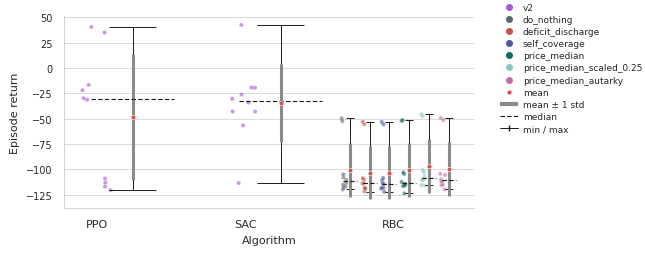

saved v2_default_20260907_193744_out_2.pdf  (v2, cum_E_kWh, default = default, 6.30 x 2.40 in)


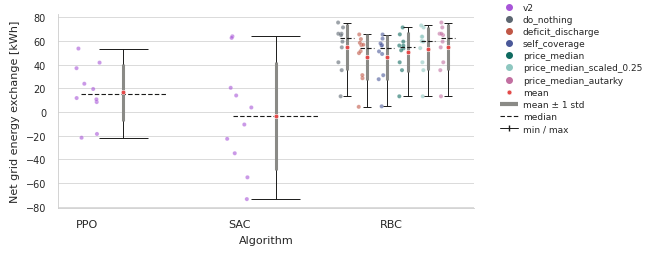

saved v2_default_20260907_193744_out_3.pdf  (v2, cum_price_EUR, default = default, 6.30 x 2.40 in)


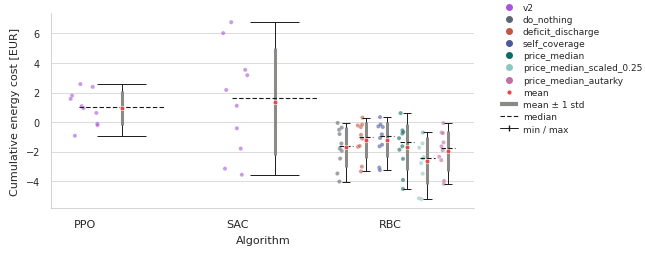

In [8]:
# One run = every (group, metric, eval setting) figure. A group's figures come out
# consecutively — the metrics of METRICS, each over the group's settings in
# `group_setting_labels` order, sharing a y-axis when SHARE_Y_ACROSS_EVAL_CFGS is set —
# so one active group's PDFs are exactly the set meant to be stacked on one A4 page.
for group_name in group_labels:
    print(f"\n===== group '{group_name}' — {SNAPSHOT_GROUPS[group_name].get('label', '')}")
    for metric in present_metrics:
        shared_ylim = _shared_ylim(group_name, metric) if SHARE_Y_ACROSS_EVAL_CFGS else None
        for eval_cfg in group_setting_labels[group_name]:
            catplot_for_metric(group_name, metric, eval_cfg, ylim=shared_ylim)

## Per-strip statistics

One row per (group, eval setting, algorithm, variant) — the exact values behind the stat glyphs,
over that strip's pooled episodes: `count`, `mean` (red dot), `std` (grey-bar half-length),
`median` (dashed line), `min` and `max` per metric. Rows follow the figure order: groups as
drawn, then their settings, x-axis algorithms and dodged variants.

To export these numbers (CSV + LaTeX body, settings side by side as columns) run
`sps_eval_stats_table_algo_cmp.ipynb` — it reuses this notebook's main-input, discovery and load
cells, so it picks up exactly the same data.

In [9]:
strip_stats = _in_figure_order(
    episodes.groupby(["group", "eval_cfg", "algo", "variant"])[present_metrics].agg(
        ["count", "mean", "std", "median", "min", "max"])
)
strip_stats

total_reward              \
                                                    count        mean   
group eval_cfg algo variant                                             
v2    default  PPO  v2                                 10  -48.289717   
               SAC  v2                                 10  -34.200388   
               RBC  do_nothing                         10 -100.704808   
                    deficit_discharge                  10 -103.147541   
                    self_coverage                      10 -103.237904   
                    price_median                       10 -100.822592   
                    price_median_scaled_0.25           10  -96.375289   
                    price_median_autarky               10  -99.385154   

                                                                     \
                                                    std      median   
group eval_cfg algo variant                                           
v2    default  PPO  v2                        62.288128  -30.508714   
               SAC  v2                        38.454158  -32.109054   
               RBC  do_nothing                26.583461 -111.774365   
                    deficit_discharge         26.115904 -113.725037   
                    self_coverage             26.078168 -113.925702   
                    price_median              26.520016 -113.233825   
                    price_median_scaled_0.25  26.762800 -108.084712   
                    price_median_autarky      26.286917 -110.669830   

                                                                    cum_E_kWh  \
                                                     min        max     count   
group eval_cfg algo variant                                                     
v2    default  PPO  v2                       -120.380680  40.509273        10   
               SAC  v2                       -113.314235  42.449740        10   
               RBC  do_nothing               -119.623030 -49.701606        10   
                    deficit_discharge        -121.816989 -53.018885        10   
                    self_coverage            -122.032770 -53.146755        10   
                    price_median             -123.665446 -51.350925        10   
                    price_median_scaled_0.25 -115.777558 -45.431778        10   
                    price_median_autarky     -119.581945 -49.242591        10   

                                                                               \
                                                   mean        std     median   
group eval_cfg algo variant                                                     
v2    default  PPO  v2                        16.652223  24.284668  15.642051   
               SAC  v2                        -3.182123  45.741637  -3.358013   
               RBC  do_nothing                54.918289  19.315969  62.228500   
                    deficit_discharge         46.447037  19.169041  54.019257   
                    self_coverage             46.224016  19.098326  53.731502   
                    price_median              50.550885  16.706585  54.968859   
                    price_median_scaled_0.25  53.605789  18.466003  59.728500   
                    price_median_autarky      54.918289  19.315969  62.228500   

                                                                    \
                                                    min        max   
group eval_cfg algo variant                                          
v2    default  PPO  v2                       -21.695903  53.632316   
               SAC  v2                       -73.544580  63.962547   
               RBC  do_nothing                13.284521  75.614825   
                    deficit_discharge          4.395308  65.541123   
                    self_coverage              4.824829  65.479088   
                    price_median              13.284521  71.478242   
                    price_median_scaled_0.25 

## Variance across eval seeds, per (group, eval setting, algorithm, variant)

Per strip, the metric mean is first taken within each eval seed, then aggregated (`mean` / `std`
/ `min` / `max`) across seeds — a small `std` means the result is consistent across eval seeds
rather than a lucky episode draw. With one seed per source the `std` is `NaN` and
`min` = `mean` = `max`; it only becomes informative once `_seed<N>` fan-outs exist and `SEEDS`
keeps more than one (it is pinned to `[42]` above).

In [10]:
# dropna=False because `seed` is a GROUP KEY here and may be None: the discovery cell
# keeps CSVs whose seed it cannot resolve (with a warning) when no seed filter is set,
# and pandas' default `dropna=True` would silently drop those episodes from this table
# — potentially the whole strip (pandas/core/shared_docs.py: "If True, and if group keys
# contain NA values, NA values together with row/column will be dropped").
seed_means = episodes.groupby(["group", "eval_cfg", "algo", "variant", "seed"],
                              dropna=False)[present_metrics].mean()
_in_figure_order(seed_means.groupby(["group", "eval_cfg", "algo", "variant"]).agg(
    ["mean", "std", "min", "max"]))

total_reward                  \
                                                     mean std         min   
group eval_cfg algo variant                                                 
v2    default  PPO  v2                         -48.289717 NaN  -48.289717   
               SAC  v2                         -34.200388 NaN  -34.200388   
               RBC  do_nothing                -100.704808 NaN -100.704808   
                    deficit_discharge         -103.147541 NaN -103.147541   
                    self_coverage             -103.237904 NaN -103.237904   
                    price_median              -100.822592 NaN -100.822592   
                    price_median_scaled_0.25   -96.375289 NaN  -96.375289   
                    price_median_autarky       -99.385154 NaN  -99.385154   

                                                          cum_E_kWh      \
                                                     max       mean std   
group eval_cfg algo variant                                               
v2    default  PPO  v2                        -48.289717  16.652223 NaN   
               SAC  v2                        -34.200388  -3.182123 NaN   
               RBC  do_nothing               -100.704808  54.918289 NaN   
                    deficit_discharge        -103.147541  46.447037 NaN   
                    self_coverage            -103.237904  46.224016 NaN   
                    price_median             -100.822592  50.550885 NaN   
                    price_median_scaled_0.25  -96.375289  53.605789 NaN   
                    price_median_autarky      -99.385154  54.918289 NaN   

                                                                    \
                                                    min        max   
group eval_cfg algo variant                                          
v2    default  PPO  v2                        16.652223  16.652223   
               SAC  v2                        -3.182123  -3.182123   
               RBC  do_nothing                54.918289  54.918289   
                    deficit_discharge         46.447037  46.447037   
                    self_coverage             46.224016  46.224016   
                    price_median              50.550885  50.550885   
                    price_median_scaled_0.25  53.605789  53.605789   
                    price_median_autarky      54.918289  54.918289   

                                             cum_price_EUR                \
                                                      mean std       min   
group eval_cfg algo variant                                                
v2    default  PPO  v2                            0.967737 NaN  0.967737   
               SAC  v2                            1.381806 NaN  1.381806   
               RBC  do_nothing                   -1.696974 NaN -1.696974   
                    deficit_discharge            -1.209230 NaN -1.209230   
                    self_coverage                -1.188786 NaN -1.188786   
                    price_median                 -1.696848 NaN -1.696848   
                    price_median_scaled_0.25     -2.609752 NaN -2.609752   
                    price_median_autarky         -1.955939 NaN -1.955939   

                                                        
                                                   max  
group eval_cfg algo variant                             
v2    default  PPO  v2                        0.967737  
               SAC  v2                        1.381806  
               RBC  do_nothing               -1.696974  
                    deficit_discharge        -1.209230  
                    self_coverage            -1.188786  
                    price_median             -1.696848  
                    price_median_scaled_0.25 -2.609752  
                    price_median_autarky     -1.955939

## Per-step trajectories — the input for the EV and BES analyses

The eval CSVs carry only per-episode totals, so the EV-session counts and the battery summary are
computed from the **per-step trajectories** written next to every eval CSV
(`<result dir>/trajectories/<episode>_trajectory.json`). Only the runs that survived the seed and
duplicate filtering above are read, so the trajectories always belong to the episodes drawn in
the figures — and only for the **active groups**.

The columns used (all verified present in these snapshots' trajectory JSONs):

| Column | Meaning |
|---|---|
| `state.s_evc_connected` | 1 while the charger holds an EV; the charger applies the schedule's connect/disconnect in `exec_action`, so this flips one step after `ctxt_ev_schedule_max_cap_kWh` |
| `state.s_evc_soc`, `state.s_evc_target_soc` | EV SoC and its session target — both **zeroed on detach** (`LinearEVCharger.set_ev_connected` clears `soc`, and `target_soc` returns 0.0 with no `ev_spec`), so a session's verdict must be read from its **last connected** row |
| `state.s_evc_session_target_feasible` | snapshotted at connect: can the target still be reached at full charging rate? |
| `state.s_battery_soc` | battery SoC |
| `state.s_sim_time` | episode progress; hour of day = `s_sim_time × 24` for these one-day episodes |
| `power_breakdown.battery` | the step's battery power as `production − consumption` (`extract_trajectory_from_infos`), i.e. **positive = discharge**, negative = charge |

Row 0 of every column is the reset row (zero action, zero power), so step `t ≥ 1` acted under the
state of row `t − 1` — which is what the hour-of-day binning below uses.

In [11]:
# Reading one group's trajectories is ~80 JSON files of ~0.4 MB; cached so re-running
# the analysis cells below is instant.
@lru_cache(maxsize=None)
def _load_trajectory(path: str) -> dict:
    return json.loads(Path(path).read_text())["trajectory"]


def _column(trajectory: dict, section: str, key: str) -> np.ndarray | None:
    """One columnar trajectory series as a float array, or None when absent."""
    values = trajectory.get(section, {}).get(key)
    return None if values is None else np.asarray(values, dtype=float).ravel()


# Every trajectory JSON of the kept eval records, in figure order. `result_dir` is the
# directory the eval CSV sits in, and the eval writers put `trajectories/` right beside
# it (both for the flat STA layout and the per-config GEN dirs).
def _trajectory_records() -> list[dict]:
    records = []
    for record in eval_records:
        trajectory_dir = record["result_dir"] / "trajectories"
        paths = sorted(trajectory_dir.glob("*_trajectory.json"),
                       key=lambda path: int(path.name.split("_")[0]))
        if not paths:
            print(f"WARNING: no trajectories under {trajectory_dir} — "
                  f"'{record['group']} / {record['algo']} — {record['variant']}' is absent "
                  "from the EV and BES analyses.")
            continue
        for path in paths:
            records.append({
                "group": record["group"], "algo": record["algo"], "variant": record["variant"],
                "eval_cfg": record["setting"], "seed": record["seed"],
                "snapshot_dir": record["snapshot_dir"],
                "episode": int(path.name.split("_")[0]), "path": path,
            })
    return records


trajectory_records = _trajectory_records()
print(f"{len(trajectory_records)} eval-episode trajectories over "
      f"{len({record['path'].parent for record in trajectory_records})} result directories")

80 eval-episode trajectories over 8 result directories


## EV charging success

One charging **session** is a maximal run of connected steps. It ends when the charger releases
the EV — the `s_evc_connected` 1 → 0 edge — and that is the step `EVChargingSessionReward` issues
its verdict on:

```python
if was_connected and not now_connected:
    achieved_soc = float(state["s_evc_soc"][0])          # pre-detach row
    target_soc = session_target_soc(info)                # latched, not cleared on detach
    return self.weight * (self.success_reward
                          if achieved_soc >= target_soc - self.disconnect_soc_tolerance
                          else self.failure_penalty)
```

so the table below reads `s_evc_soc` and `s_evc_target_soc` from the session's **last connected**
row and reports both columns asked for:

- **met@tol** — `achieved ≥ target − EV_SOC_TOLERANCE`, reproducing the verdict the policy was
  rewarded on (`disconnect_soc_tolerance = 0.05` in every trial YAML of these snapshots);
- **met@strict** — `achieved ≥ target`, with no tolerance.

A session still connected at the horizon gets **no** verdict (the reward never fires either); it
is counted in the `open` column and excluded from the rates. `infeasible` counts sessions whose
`s_evc_session_target_feasible` was 0 — the target was already unreachable at full charging rate
when the EV plugged in, so the miss is not the policy's doing.

Note on the rule-based rows: `RuleBasedStrategy` only ever emits battery actions
(`_battery_action` / `zero_action` in `adv_building_gym/rbc_strats/base.py`), so `a_lin_ev_charger`
stays 0 for every RBC strategy and no session can be met. Their 0 % is the *no-EV-control*
reference, not a failed controller.

In [12]:
# One row per charging session of one episode. The charger zeroes s_evc_soc and
# s_evc_target_soc on detach, so achieved SoC and target are read from the session's
# LAST CONNECTED row — the same row EVChargingSessionReward judges as `state` (s).
def ev_sessions(trajectory: dict) -> list[dict]:
    connected = _column(trajectory, "state", "s_evc_connected")
    soc = _column(trajectory, "state", "s_evc_soc")
    target = _column(trajectory, "state", "s_evc_target_soc")
    feasible = _column(trajectory, "state", "s_evc_session_target_feasible")
    if connected is None or soc is None or target is None:
        return []

    plugged = connected > 0.5
    indices = np.flatnonzero(plugged)
    if indices.size == 0:
        return []
    segments = np.split(indices, np.flatnonzero(np.diff(indices) != 1) + 1)

    sessions = []
    for segment in segments:
        first, last = int(segment[0]), int(segment[-1])
        achieved, wanted = float(soc[last]), float(target[last])
        sessions.append({
            "start_step": first,
            "end_step": last,
            "steps_connected": len(segment),
            "achieved_soc": achieved,
            "target_soc": wanted,
            "soc_gap": max(0.0, wanted - achieved),
            "met_tolerance": bool(achieved >= wanted - EV_SOC_TOLERANCE),
            "met_strict": bool(achieved >= wanted),
            "feasible": bool(feasible[last] > 0.5) if feasible is not None else True,
            # No disconnect edge inside the episode -> no verdict is ever issued.
            "open_at_horizon": last == plugged.size - 1,
        })
    return sessions


ev_session_rows = []
for record in trajectory_records:
    trajectory = _load_trajectory(str(record["path"]))
    for session in ev_sessions(trajectory):
        ev_session_rows.append({
            "group": record["group"], "algo": record["algo"], "variant": record["variant"],
            "eval_cfg": record["eval_cfg"], "seed": record["seed"], "episode": record["episode"],
            **session,
        })

ev_sessions_frame = pd.DataFrame(ev_session_rows)
if ev_sessions_frame.empty:
    raise ValueError("No EV charging sessions found in any trajectory — is this an EV trial?")

_keys = ["group", "eval_cfg", "algo", "variant"]
# Eval episodes per strip, counted from the trajectories rather than from the sessions:
# an episode whose eval day schedules no EV at all (the `_eval_ch` groups have some)
# contributes no session but is still an evaluated episode.
_strip_episodes = pd.DataFrame(trajectory_records).groupby(_keys)["episode"].nunique()
# Sessions with a verdict; the ones still connected at the horizon are counted apart.
# `infeasible` is materialised as a column so it sums like the other counts instead of
# needing a per-group Python lambda.
_closed = ev_sessions_frame[~ev_sessions_frame["open_at_horizon"]].assign(
    infeasible=lambda frame: ~frame["feasible"])
_closed_by_strip = _closed.groupby(_keys)

ev_success = pd.DataFrame({
    "episodes": _strip_episodes,
    "episodes_with_session": ev_sessions_frame.groupby(_keys)["episode"].nunique(),
    "sessions": _closed_by_strip.size(),
    "met@tol": _closed_by_strip["met_tolerance"].sum(),
    "rate@tol": _closed_by_strip["met_tolerance"].mean(),
    "met@strict": _closed_by_strip["met_strict"].sum(),
    "rate@strict": _closed_by_strip["met_strict"].mean(),
    "mean_soc_gap": _closed_by_strip["soc_gap"].mean(),
    "max_soc_gap": _closed_by_strip["soc_gap"].max(),
    "infeasible": _closed_by_strip["infeasible"].sum(),
    "open": ev_sessions_frame.groupby(_keys)["open_at_horizon"].sum(),
}).reindex(_strip_episodes.index)
# A strip whose episodes hold no session at all: zero counts, undefined rates.
ev_success[["episodes_with_session", "sessions", "met@tol", "met@strict", "infeasible", "open"]] = (
    ev_success[["episodes_with_session", "sessions", "met@tol", "met@strict", "infeasible", "open"]]
    .fillna(0).astype(int)
)
ev_success = _in_figure_order(ev_success)
ev_success.round(3)

episodes  episodes_with_session  \
group eval_cfg algo variant                                                     
v2    default  PPO  v2                              10                     10   
               SAC  v2                              10                     10   
               RBC  do_nothing                      10                     10   
                    deficit_discharge               10                     10   
                    self_coverage                   10                     10   
                    price_median                    10                     10   
                    price_median_scaled_0.25        10                     10   
                    price_median_autarky            10                     10   

                                              sessions  met@tol  rate@tol  \
group eval_cfg algo variant                                                 
v2    default  PPO  v2                              18        6     0.333   
               SAC  v2                              18        8     0.444   
               RBC  do_nothing                      18        0     0.000   
                    deficit_discharge               18        0     0.000   
                    self_coverage                   18        0     0.000   
                    price_median                    18        0     0.000   
                    price_median_scaled_0.25        18        0     0.000   
                    price_median_autarky            18        0     0.000   

                                              met@strict  rate@strict  \
group eval_cfg algo variant                                             
v2    default  PPO  v2                                 6        0.333   
               SAC  v2                                 6        0.333   
               RBC  do_nothing                         0        0.000   
                    deficit_discharge                  0        0.000   
                    self_coverage                      0        0.000   
                    price_median                       0        0.000   
                    price_median_scaled_0.25           0        0.000   
                    price_median_autarky               0        0.000   

                                              mean_soc_gap  max_soc_gap  \
group eval_cfg algo variant                                               
v2    default  PPO  v2                               0.202        0.550   
               SAC  v2                               0.128        0.438   
               RBC  do_nothing                       0.459        0.570   
                    deficit_discharge                0.459        0.570   
                    self_coverage                    0.459        0.570   
                    price_median                     0.459        0.570   
                    price_median_scaled_0.25         0.459        0.570   
                    price_median_autarky             0.459        0.570   

                                              infeasible  open  
group eval_cfg algo variant                                     
v2    default  PPO  v2                                 0     0  
               SAC  v2                                 0     0  
               RBC  do_nothing                         0     0  
                    deficit_discharge                  0     0  
                    self_coverage                      0     0  
                    price_median                       0     0  
                    price_median_scaled_0.25           0     0  
                    price_median_autarky               0     0

## BES management summary

How the battery is actually used, per strip. The step's battery power comes from
`power_breakdown.battery`, which `extract_trajectory_from_infos` writes as
`production − consumption` — so **positive = discharge**, negative = charge — and the step energy
is that power times the snapshot's own `control_step` in hours.

Per episode:

| Column | Meaning |
|---|---|
| `charged_kWh` / `discharged_kWh` | energy in / out over the episode |
| `charge_ratio` | `charged_kWh / discharged_kWh` — 0 means the battery is only emptied |
| `early_share` | share of the episode's total `|battery power|` spent before `EARLY_HOURS_END` |
| `dir_changes` | charge ↔ discharge sign flips, ignoring power below `POWER_DEADBAND_KW` |
| `start_soc` / `end_soc` / `min_soc` / `max_soc` | SoC trajectory endpoints and extremes |
| `soc_recovery` | how far the SoC climbs back **after** its lowest point |

### The two flags

Both readings of *"the BES does no more than discharge at the beginning of the day"* are reported
side by side, so a disagreement is visible instead of hidden behind one threshold:

- **`flag_throughput`** — `early_share ≥ EARLY_SHARE_FLAG` **and** `charge_ratio <
  RECHARGE_RATIO_FLAG`: the activity is concentrated in the early hours *and* the battery is
  barely refilled.
- **`flag_soc_shape`** — `soc_recovery ≤ SOC_RECOVERY_TOLERANCE`: the SoC falls to its minimum and
  never climbs back, whatever the timing.

An episode whose total throughput stays under `IDLE_THROUGHPUT_KWH` is classified **idle** and
flagged by neither — an untouched battery (`do_nothing`) is not a drawdown, and without that guard
its zero recovery would trip `flag_soc_shape`. The `flag_*` columns of the summary are the
**fraction of that strip's episodes** carrying the flag; `idle` is the fraction classified idle.

In [13]:
# One row per episode: how the battery moved. Row 0 of every column is the reset row
# (zero action), so step t >= 1 acted under the state of row t - 1 — which is the row
# the hour-of-day binning reads.
def bes_metrics(trajectory: dict, control_step_s: int) -> dict | None:
    power = _column(trajectory, "power_breakdown", "battery")   # >0 discharge, <0 charge
    soc = _column(trajectory, "state", "s_battery_soc")
    sim_time = _column(trajectory, "state", "s_sim_time")
    if power is None or soc is None or sim_time is None:
        return None

    step_hours = control_step_s / 3600.0
    acting_power = power[1:]
    acting_hour = sim_time[:-1] * 24.0
    discharged = float(np.clip(acting_power, 0.0, None).sum() * step_hours)
    charged = float(np.clip(-acting_power, 0.0, None).sum() * step_hours)

    throughput = np.abs(acting_power)
    total_throughput = float(throughput.sum() * step_hours)
    early_share = (float(throughput[acting_hour < EARLY_HOURS_END].sum() / throughput.sum())
                   if throughput.sum() > 0 else np.nan)
    charge_ratio = charged / discharged if discharged > 0 else np.nan

    directions = np.sign(np.where(np.abs(acting_power) > POWER_DEADBAND_KW, acting_power, 0.0))
    directions = directions[directions != 0.0]
    direction_changes = int((np.diff(directions) != 0).sum()) if directions.size > 1 else 0

    # SoC shape: does the SoC ever climb back after its lowest point of the episode?
    trough = int(np.argmin(soc))
    soc_recovery = float(soc[trough:].max() - soc[trough])

    idle = total_throughput < IDLE_THROUGHPUT_KWH
    return {
        "charged_kWh": charged,
        "discharged_kWh": discharged,
        "throughput_kWh": total_throughput,
        "charge_ratio": charge_ratio,
        "early_share": early_share,
        "dir_changes": direction_changes,
        "start_soc": float(soc[0]),
        "end_soc": float(soc[-1]),
        "min_soc": float(soc.min()),
        "max_soc": float(soc.max()),
        "soc_recovery": soc_recovery,
        "idle": bool(idle),
        # Concentrated early AND barely refilled.
        "flag_throughput": bool(not idle and early_share >= EARLY_SHARE_FLAG
                                and (np.isnan(charge_ratio) or charge_ratio < RECHARGE_RATIO_FLAG)),
        # Drawn down, then flat — the SoC never recovers.
        "flag_soc_shape": bool(not idle and soc_recovery <= SOC_RECOVERY_TOLERANCE),
    }


bes_rows = []
for record in trajectory_records:
    control_step_s = snapshot_fingerprints[record["snapshot_dir"]]["control_step_s"]
    metrics = bes_metrics(_load_trajectory(str(record["path"])), control_step_s)
    if metrics is None:
        continue
    bes_rows.append({
        "group": record["group"], "algo": record["algo"], "variant": record["variant"],
        "eval_cfg": record["eval_cfg"], "seed": record["seed"], "episode": record["episode"],
        **metrics,
    })

bes_episodes = pd.DataFrame(bes_rows)
if bes_episodes.empty:
    raise ValueError("No battery trajectories found — is there a battery in this trial?")

_bes_means = ["charged_kWh", "discharged_kWh", "charge_ratio", "early_share", "dir_changes",
              "start_soc", "end_soc", "min_soc", "max_soc", "soc_recovery"]
# Where the two criteria disagree — the reason both are reported. Derived as a plain
# boolean column so it aggregates with everything else: a groupby-apply would need
# `include_groups`, which only exists in pandas >= 2.2 and is deprecated in that very
# release (pandas/core/groupby/groupby.py: "versionadded:: 2.2.0" / "deprecated:: 2.2.0").
bes_episodes["flags_disagree"] = bes_episodes["flag_throughput"] != bes_episodes["flag_soc_shape"]

# The flag_* / idle / flags_disagree columns are booleans, so their mean is the FRACTION
# of that strip's episodes carrying the flag.
bes_summary = _in_figure_order(bes_episodes.groupby(_keys).agg(
    episodes=("episode", "size"),
    **{column: (column, "mean") for column in _bes_means},
    idle=("idle", "mean"),
    flag_throughput=("flag_throughput", "mean"),
    flag_soc_shape=("flag_soc_shape", "mean"),
    flags_disagree=("flags_disagree", "mean"),
))
bes_summary.round(3)

episodes  charged_kWh  \
group eval_cfg algo variant                                           
v2    default  PPO  v2                              10        1.197   
               SAC  v2                              10       19.854   
               RBC  do_nothing                      10        0.000   
                    deficit_discharge               10       10.863   
                    self_coverage                   10       10.594   
                    price_median                    10       24.044   
                    price_median_scaled_0.25        10       16.145   
                    price_median_autarky            10       11.113   

                                              discharged_kWh  charge_ratio  \
group eval_cfg algo variant                                                  
v2    default  PPO  v2                                 4.215         0.208   
               SAC  v2                                18.902         1.072   
               RBC  do_nothing                         0.000           NaN   
                    deficit_discharge                  2.392         6.321   
                    self_coverage                      1.900         7.739   
                    price_median                      19.676         1.296   
                    price_median_scaled_0.25          14.832         1.107   
                    price_median_autarky              11.113         1.000   

                                              early_share  dir_changes  \
group eval_cfg algo variant                                              
v2    default  PPO  v2                              0.687          2.2   
               SAC  v2                              0.105          6.1   
               RBC  do_nothing                        NaN          0.0   
                    deficit_discharge               0.558          4.5   
                    self_coverage                   0.585          1.2   
                    price_median                    0.570          4.3   
                    price_median_scaled_0.25        0.375          4.3   
                    price_median_autarky            0.513          2.8   

                                              start_soc  end_soc  min_soc  \
group eval_cfg algo variant                                                 
v2    default  PPO  v2                            0.289    0.100    0.100   
               SAC  v2                            0.289    0.348    0.100   
               RBC  do_nothing                    0.289    0.289    0.289   
                    deficit_discharge             0.289    0.818    0.289   
                    self_coverage                 0.289    0.832    0.289   
                    price_median                  0.289    0.562    0.289   
                    price_median_scaled_0.25      0.289    0.371    0.289   
                    price_median_autarky          0.289    0.289    0.289   

                                              max_soc  soc_recovery  idle  \
group eval_cfg algo variant                                                 
v2    default  PPO  v2                          0.303         0.075   0.0   
               SAC  v2                          0.950         0.850   0.0   
               RBC  do_nothing                  0.289         0.000   1.0   
                    deficit_discharge           0.950         0.661   0.0   
                    self_coverage               0.950         0.661   0.0   
                    price_median                0.950         0.661   0.0   
                    price_median_scaled_0.25    0.950         0.661   0.0   
                    price_median_autarky        0.950         0.661   0.0   

                                              flag_throughput  flag_soc_shape  \
group eval_cfg algo variant                                                     
v2    default  PPO  v2                                    0.5             0.3   
               SAC  v2      

In [14]:
# Plain-language verdict per strip, so the summary reads without cross-checking thresholds.
print(f"Flags: throughput = >= {EARLY_SHARE_FLAG:.0%} of |battery power| before "
      f"{EARLY_HOURS_END:.0f}:00 AND charged/discharged < {RECHARGE_RATIO_FLAG:.0%}; "
      f"SoC shape = SoC recovers <= {SOC_RECOVERY_TOLERANCE:.2f} after its minimum; "
      f"idle = throughput < {IDLE_THROUGHPUT_KWH:.2f} kWh.\n")
for (group_name, eval_cfg, algo, variant), row in bes_summary.iterrows():
    if row["idle"] >= 0.5:
        verdict = "battery essentially untouched"
    elif row["flag_throughput"] >= 0.5 and row["flag_soc_shape"] >= 0.5:
        verdict = "DISCHARGE-ONLY EARLY — both criteria agree"
    elif row["flag_throughput"] >= 0.5:
        verdict = "early, barely-refilled throughput (SoC shape disagrees — some recovery happens)"
    elif row["flag_soc_shape"] >= 0.5:
        verdict = "SoC never recovers (but the activity is not concentrated early)"
    else:
        verdict = "active management — charges and discharges through the day"
    print(f"{group_name:<13} {algo:<4} {variant:<26} {verdict}")
    print(f"      charged {row['charged_kWh']:6.2f} kWh, discharged {row['discharged_kWh']:6.2f} kWh "
          f"(ratio {row['charge_ratio']:.2f}), early share {row['early_share']:.2f}, "
          f"{row['dir_changes']:.1f} direction changes, SoC {row['start_soc']:.2f} -> "
          f"{row['end_soc']:.2f} (min {row['min_soc']:.2f}, recovery {row['soc_recovery']:.2f})")
    print(f"      episodes flagged: throughput {row['flag_throughput']:.0%}, "
          f"SoC shape {row['flag_soc_shape']:.0%}, disagreeing {row['flags_disagree']:.0%}, "
          f"idle {row['idle']:.0%}")

Flags: throughput = >= 70% of |battery power| before 8:00 AND charged/discharged < 20%; SoC shape = SoC recovers <= 0.02 after its minimum; idle = throughput < 0.10 kWh.

v2            PPO  v2                         early, barely-refilled throughput (SoC shape disagrees — some recovery happens)
      charged   1.20 kWh, discharged   4.21 kWh (ratio 0.21), early share 0.69, 2.2 direction changes, SoC 0.29 -> 0.10 (min 0.10, recovery 0.07)
      episodes flagged: throughput 50%, SoC shape 30%, disagreeing 20%, idle 0%
v2            SAC  v2                         active management — charges and discharges through the day
      charged  19.85 kWh, discharged  18.90 kWh (ratio 1.07), early share 0.10, 6.1 direction changes, SoC 0.29 -> 0.35 (min 0.10, recovery 0.85)
      episodes flagged: throughput 0%, SoC shape 0%, disagreeing 0%, idle 0%
v2            RBC  do_nothing                 battery essentially untouched
      charged   0.00 kWh, discharged   0.00 kWh (ratio nan), early share 

### Mean battery power over the day

The same evidence as a picture: each strip's mean battery power per hour of day, averaged over its
eval episodes (**positive = discharge**, negative = charge). A strip that only empties the battery
in the morning shows one positive lump before `EARLY_HOURS_END` (marked) and a flat line
afterwards; an actively managed one alternates sign through the day.

Algorithms are separated by line style (PPO solid, SAC dashed, RBC dotted) and variants by the
`VARIANT_COLORS` colour, so the figure reads against the catplots above. Saved at the same print
size as those, one PDF per group and eval setting.

saved v2_default_bes_profile_20260907_193744_out_4.pdf  (v2, battery power over the day, default)


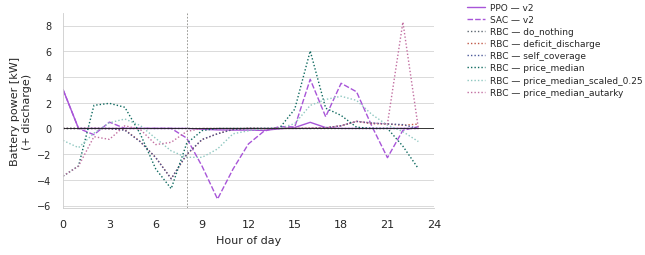

In [15]:
ALGO_LINESTYLES = {"PPO": "-", "SAC": (0, (4, 1.5)), "DreamerV3": (0, (1, 1.2)), "RBC": (0, (1, 1.5))}
PROFILE_LINEWIDTH = 1.0


# Mean battery power per hour-of-day bin for one strip, over its eval episodes.
# Row 0 is the reset row, so step t acted at the hour of row t - 1.
def _hourly_battery_power(records: list[dict]) -> pd.Series | None:
    samples = []
    for record in records:
        trajectory = _load_trajectory(str(record["path"]))
        power = _column(trajectory, "power_breakdown", "battery")
        sim_time = _column(trajectory, "state", "s_sim_time")
        if power is None or sim_time is None:
            continue
        samples.append(pd.DataFrame({"hour": np.floor(sim_time[:-1] * 24.0), "power_kW": power[1:]}))
    if not samples:
        return None
    return pd.concat(samples, ignore_index=True).groupby("hour")["power_kW"].mean()


def battery_profile_figure(group_name: str, eval_cfg: str) -> None:
    strips = [(algo, variant) for algo in group_algo_labels[group_name]
              for variant in group_variant_labels[group_name]
              if any(record["group"] == group_name and record["eval_cfg"] == eval_cfg
                     and record["algo"] == algo and record["variant"] == variant
                     for record in trajectory_records)]
    if not strips:
        print(f"no trajectories for {group_name} / {eval_cfg} — profile skipped")
        return

    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN), layout="constrained")
    handles = []
    for algo, variant in strips:
        records = [record for record in trajectory_records
                   if record["group"] == group_name and record["eval_cfg"] == eval_cfg
                   and record["algo"] == algo and record["variant"] == variant]
        profile = _hourly_battery_power(records)
        if profile is None:
            continue
        style = ALGO_LINESTYLES.get(algo, "-")
        ax.plot(profile.index, profile.to_numpy(), color=variant_palette[variant],
                linestyle=style, linewidth=PROFILE_LINEWIDTH, label=f"{algo} — {variant}")
        handles.append(Line2D([], [], color=variant_palette[variant], linestyle=style,
                              linewidth=PROFILE_LINEWIDTH, label=f"{algo} — {variant}"))

    ax.axhline(0.0, color="#1a1a19", linewidth=0.6)
    ax.axvline(EARLY_HOURS_END, color="#8a8a86", linewidth=0.6, linestyle=(0, (2, 2)))
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Battery power [kW]\n(+ discharge)")
    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 3))
    ax.grid(axis="x", visible=False)
    fig.legend(handles=handles, loc="outside right upper", title="", frameon=False,
               ncol=LEGEND_NCOL, labelspacing=0.35, handletextpad=0.5, borderaxespad=0.0)
    sns.despine(ax=ax)

    pdf_path = next_out_path("pdf", tag=f"{group_name}_{eval_cfg}_bes_profile")
    fig.savefig(pdf_path)
    print(f"saved {pdf_path.name}  ({group_name}, battery power over the day, {eval_cfg})")
    plt.show()


for group_name in group_labels:
    for eval_cfg in group_setting_labels[group_name]:
        battery_profile_figure(group_name, eval_cfg)